# BiLSTM Weekly Drought Classification - Kansas

Baseline notebook for Kansas weekly drought classification using BiLSTM.
Sections below are organized from data inspection and EDA through evaluation.


=== Missing Values ===
No missing values in selected EDA columns.

=== Summary Statistics (mean/std/min/max) ===


,mean,std,min,max
None,45.734,47.523,0.000,100.000
D0,54.266,47.523,0.000,100.000
D1,33.416,44.736,0.000,100.000
D2,18.592,37.039,0.000,100.000
D3,8.946,26.900,0.000,100.000
D4,3.233,16.708,0.000,100.000
ALLSKY_SFC_SW_DWN,16.679,6.328,4.877,28.775
PRECTOTCORR,2.055,2.229,0.000,14.328
PS,95.164,0.385,93.982,96.637
RH2M,64.144,9.234,34.003,86.189



=== Class Imbalance ===


,label,count,share_pct
0,None,7676,45.91
1,D0,3476,20.79
2,D1,2425,14.50
3,D2,1690,10.11
4,D3,899,5.38
5,D4,554,3.31


C:\Users\Naaaangg\AppData\Local\Temp\ipykernel_7056\2900644473.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[label_map[i] for i in label_counts.index], y=label_counts.values, ax=axes[0, 0], palette=label_palette)
C:\Users\Naaaangg\AppData\Local\Temp\ipykernel_7056\2900644473.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x='Class', y='PRECTOTCORR', palette=['#4C72B0', '#DD8452'], ax=axes[2, 1])


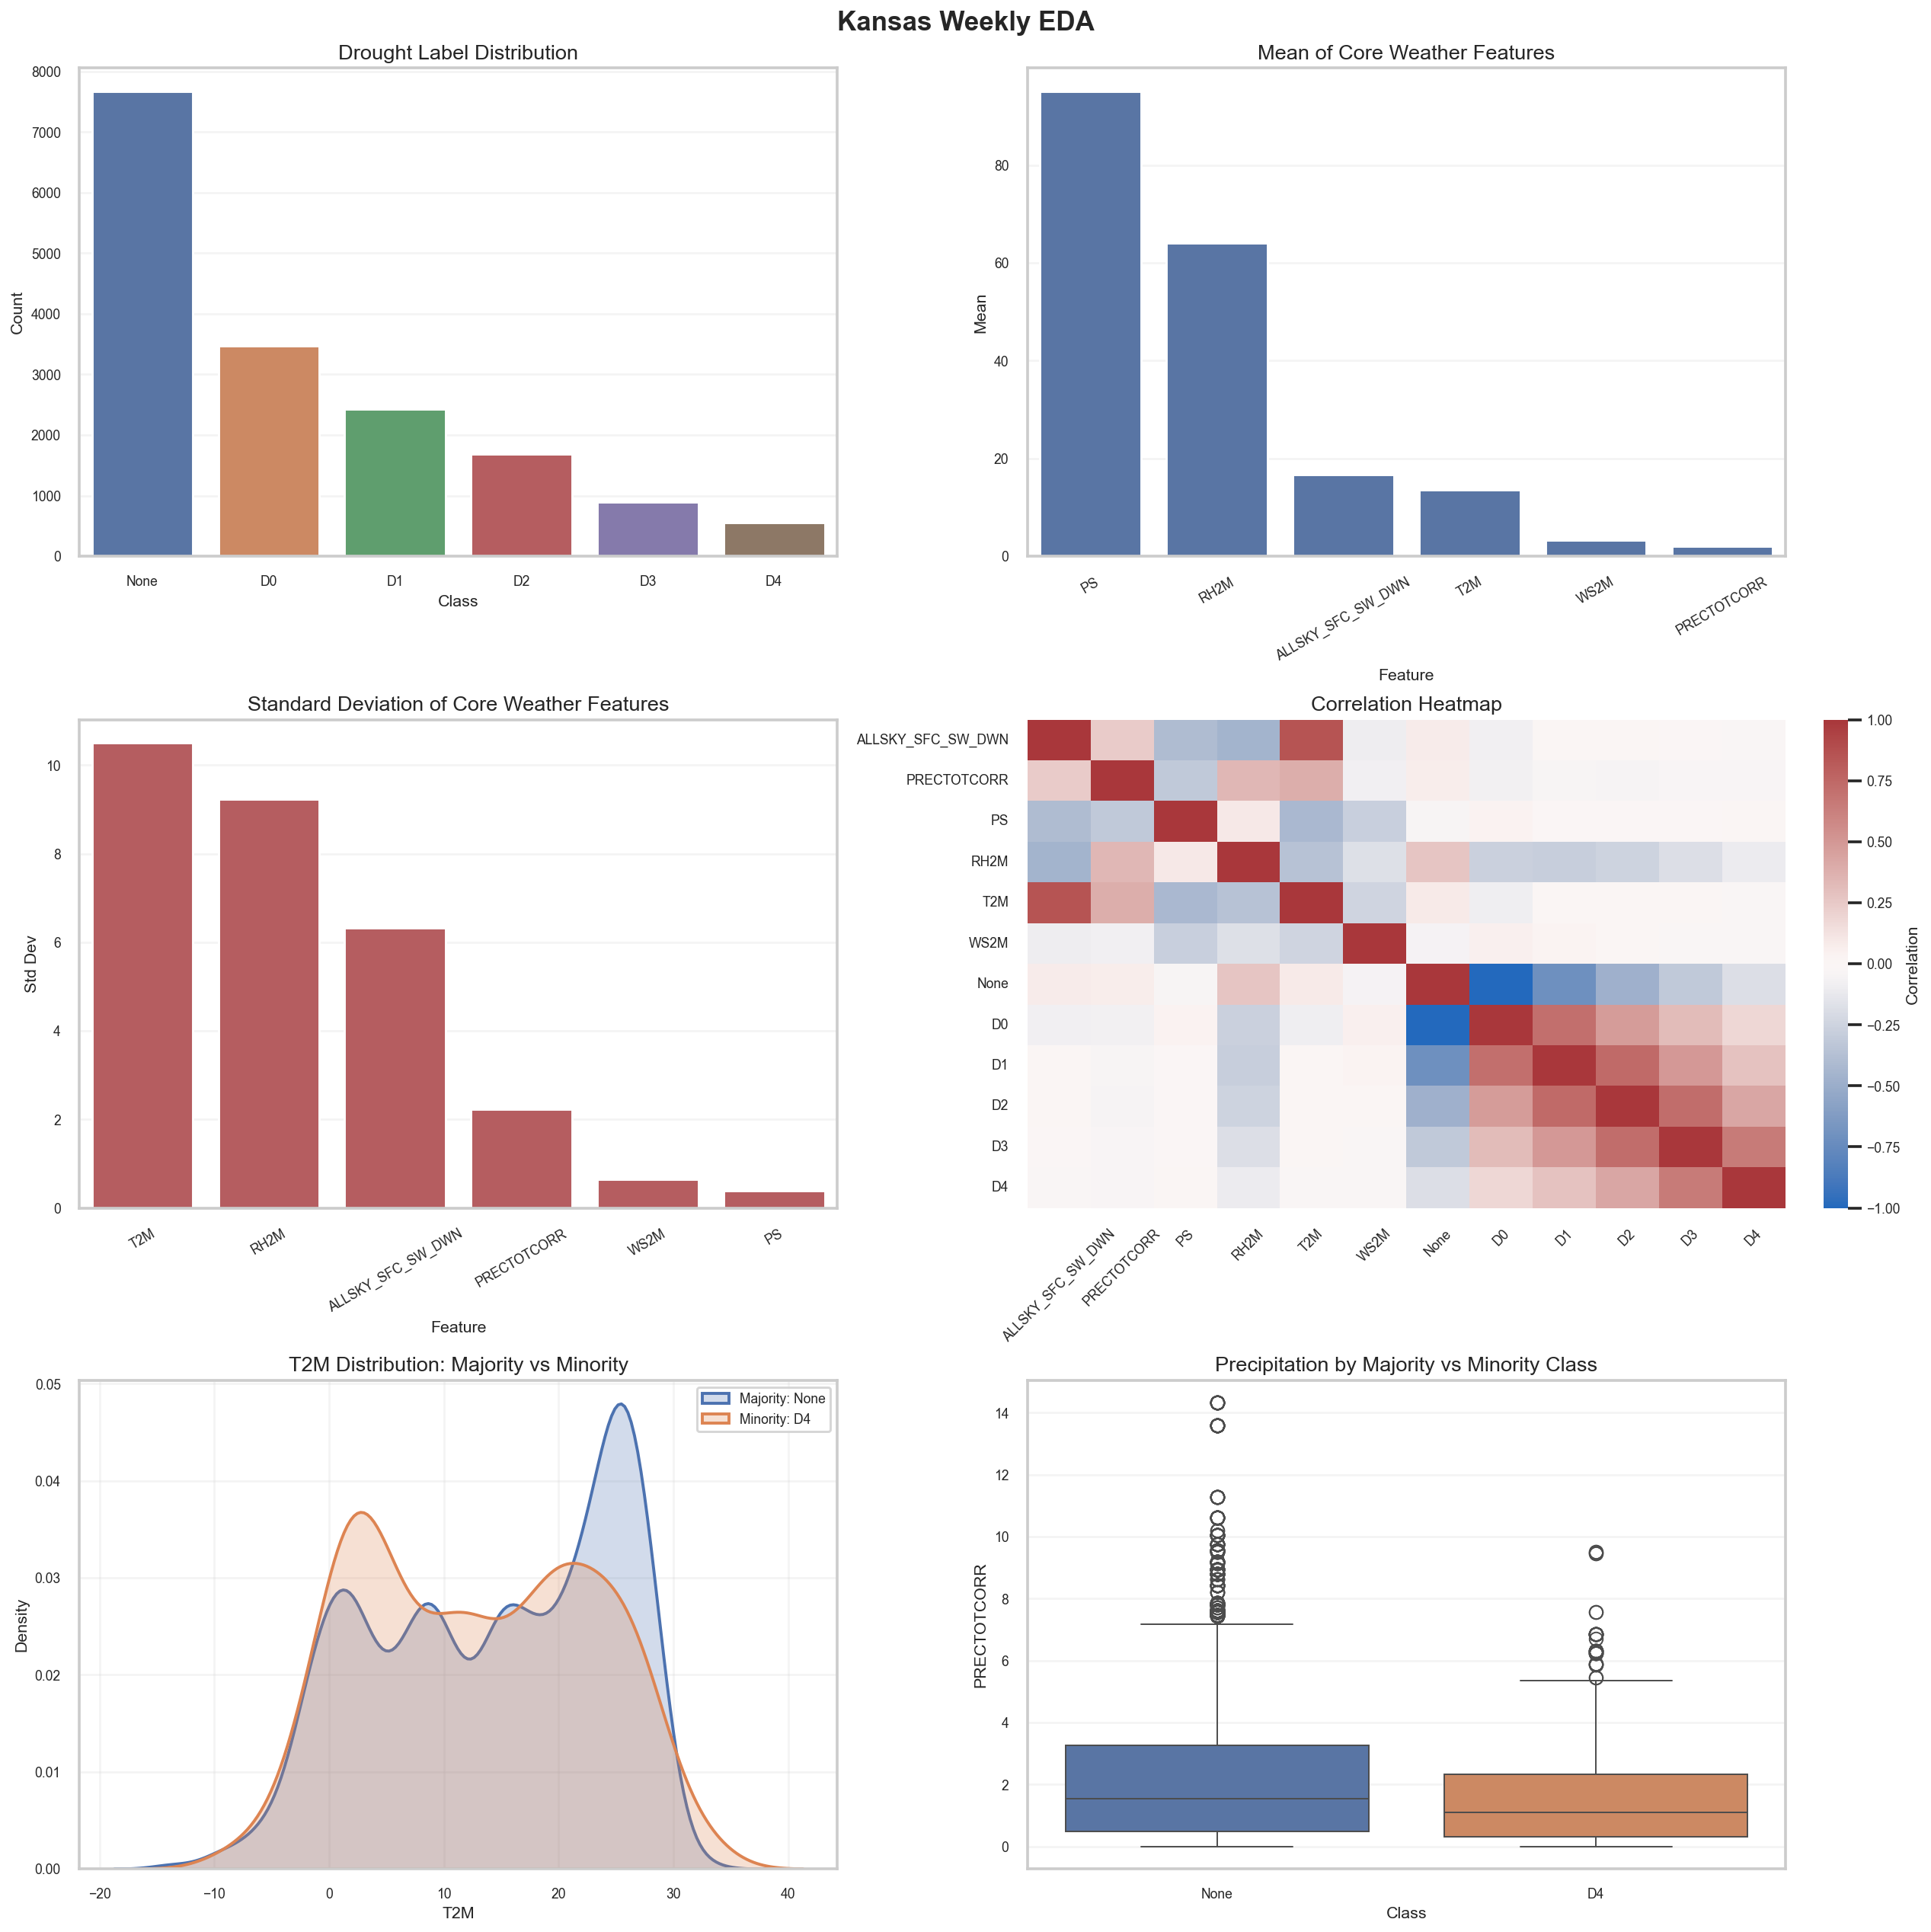

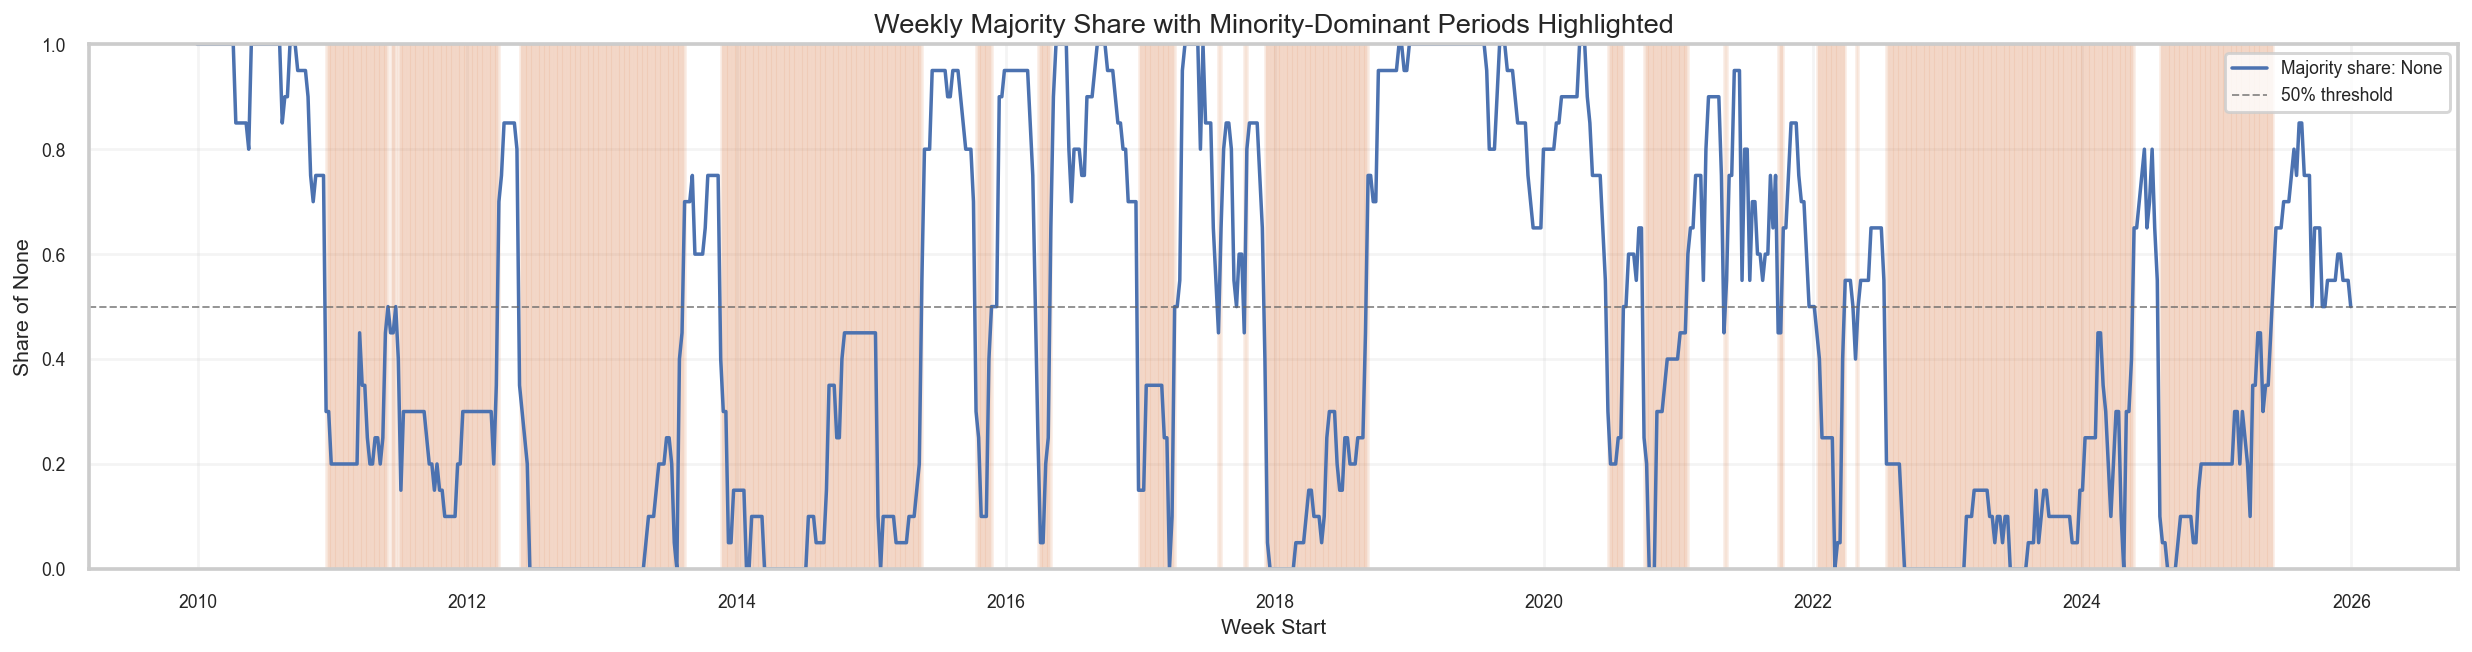

In [18]:
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 180,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

df = pd.read_csv(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])
df['ValidEnd'] = pd.to_datetime(df['ValidEnd'])
df = df.sort_values(['FIPS', 'week_start']).reset_index(drop=True)

def decumulate_drought(row):
    pmf_d4 = row['D4']
    pmf_d3 = max(0.0, row['D3'] - row['D4'])
    pmf_d2 = max(0.0, row['D2'] - row['D3'])
    pmf_d1 = max(0.0, row['D1'] - row['D2'])
    pmf_d0 = max(0.0, row['D0'] - row['D1'])
    pmf_none = max(0.0, row['None'])
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
df[pmf_cols] = df.apply(decumulate_drought, axis=1)
df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

weather_cols = ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M']
drought_cols = ['None', 'D0', 'D1', 'D2', 'D3', 'D4']
eda_cols = drought_cols + weather_cols

print('=== Missing Values ===')
missing = df[eda_cols + ['FIPS', 'week_start', 'ValidEnd']].isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if missing.empty:
    print('No missing values in selected EDA columns.')
else:
    display(missing.to_frame(name='missing_count'))

print('\n=== Summary Statistics (mean/std/min/max) ===')
eda_summary = df[eda_cols].agg(['mean', 'std', 'min', 'max']).T
display(eda_summary.round(3))

print('\n=== Class Imbalance ===')
label_counts = df['Label'].value_counts().sort_index()
label_df = pd.DataFrame({
    'label': [label_map[i] for i in label_counts.index],
    'count': label_counts.values,
    'share_pct': (label_counts.values / label_counts.sum() * 100).round(2),
})
display(label_df)

majority_label = int(label_counts.idxmax())
minority_label = int(label_counts.idxmin())
majority_name = label_map[majority_label]
minority_name = label_map[minority_label]

fig, axes = plt.subplots(3, 2, figsize=(18, 18), constrained_layout=True)
fig.suptitle('Kansas Weekly EDA', fontsize=18, fontweight='bold')

label_palette = sns.color_palette('deep', n_colors=len(label_counts))
sns.barplot(x=[label_map[i] for i in label_counts.index], y=label_counts.values, ax=axes[0, 0], palette=label_palette)
axes[0, 0].set_title('Drought Label Distribution')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].grid(alpha=0.2, axis='y')

feature_means = df[weather_cols].mean().sort_values(ascending=False)
sns.barplot(x=feature_means.index, y=feature_means.values, ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Mean of Core Weather Features')
axes[0, 1].set_xlabel('Feature')
axes[0, 1].set_ylabel('Mean')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(alpha=0.2, axis='y')

feature_std = df[weather_cols].std().sort_values(ascending=False)
sns.barplot(x=feature_std.index, y=feature_std.values, ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Standard Deviation of Core Weather Features')
axes[1, 0].set_xlabel('Feature')
axes[1, 0].set_ylabel('Std Dev')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(alpha=0.2, axis='y')

corr = df[weather_cols + drought_cols].corr()
sns.heatmap(corr, cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[1, 1], square=False, cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Heatmap')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

majority_mask = df['Label'] == majority_label
minority_mask = df['Label'] == minority_label
sns.kdeplot(data=df.loc[majority_mask, 'T2M'], ax=axes[2, 0], label=f'Majority: {majority_name}', color='#4C72B0', fill=True, alpha=0.25, linewidth=2)
sns.kdeplot(data=df.loc[minority_mask, 'T2M'], ax=axes[2, 0], label=f'Minority: {minority_name}', color='#DD8452', fill=True, alpha=0.25, linewidth=2)
axes[2, 0].set_title('T2M Distribution: Majority vs Minority')
axes[2, 0].set_xlabel('T2M')
axes[2, 0].set_ylabel('Density')
axes[2, 0].legend(frameon=True)
axes[2, 0].grid(alpha=0.2)

box_df = df[df['Label'].isin([majority_label, minority_label])].copy()
box_df['Class'] = box_df['Label'].map(label_map)
sns.boxplot(data=box_df, x='Class', y='PRECTOTCORR', palette=['#4C72B0', '#DD8452'], ax=axes[2, 1])
axes[2, 1].set_title('Precipitation by Majority vs Minority Class')
axes[2, 1].set_xlabel('Class')
axes[2, 1].set_ylabel('PRECTOTCORR')
axes[2, 1].grid(alpha=0.2, axis='y')

plt.show()

weekly_counts = df.groupby(['week_start', 'Label']).size().unstack(fill_value=0).sort_index()
weekly_majority_share = (weekly_counts.get(majority_label, 0) / weekly_counts.sum(axis=1)).fillna(0)
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(weekly_majority_share.index, weekly_majority_share.values, color='#4C72B0', linewidth=1.8, label=f'Majority share: {majority_name}')
ax.axhline(0.5, color='#666666', linestyle='--', linewidth=1, alpha=0.7, label='50% threshold')
minority_periods = weekly_majority_share.index[weekly_majority_share.values < 0.5]
for ts in minority_periods:
    ax.axvspan(ts, ts + pd.Timedelta(days=7), color='#DD8452', alpha=0.12)
ax.set_title('Weekly Majority Share with Minority-Dominant Periods Highlighted')
ax.set_xlabel('Week Start')
ax.set_ylabel(f'Share of {majority_name}')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 4. Label Construction

Convert cumulative drought categories into mutually exclusive PMF labels.


In [5]:
df = pd.read_csv(DATA_PATH)
df['week_start'] = pd.to_datetime(df['week_start'])
df['ValidEnd'] = pd.to_datetime(df['ValidEnd'])
df = df.sort_values(['FIPS', 'week_start']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Unique counties: {df["FIPS"].nunique()}')
print(f'Date range: {df["week_start"].min().date()} to {df["week_start"].max().date()}')
print(df.head())



Shape: (16720, 20)
Unique counties: 20
Date range: 2009-12-29 to 2025-12-30
  week_start   ValidEnd  Year  Month  YearWeek   FIPS        County State  \
0 2009-12-29 2010-01-04  2009     12    200953  20001  Allen County    KS   
1 2010-01-05 2010-01-11  2010      1    201001  20001  Allen County    KS   
2 2010-01-12 2010-01-18  2010      1    201002  20001  Allen County    KS   
3 2010-01-19 2010-01-25  2010      1    201003  20001  Allen County    KS   
4 2010-01-26 2010-02-01  2010      1    201004  20001  Allen County    KS   

   ALLSKY_SFC_SW_DWN  PRECTOTCORR         PS       RH2M       T2M      WS2M  \
0           6.424625     0.281375  96.380500  85.468625 -9.298000  2.292375   
1           8.633143     0.228143  96.308000  80.965000 -9.317357  3.441643   
2           8.845143     0.023071  95.363714  85.271071  1.079714  2.279500   
3           7.583786     0.590286  93.982071  80.399571  2.468286  4.079071   
4           8.431714     0.984714  95.652714  76.353500 -2.827214 

## 5. Feature Engineering

Create lagged, rolling, seasonal, and interaction features.


## 6. Temporal Split and Scaling

Split by date, then scale features using train-only statistics.


In [ ]:
def decumulate_drought(row):
    pmf_d4 = row['D4']
    pmf_d3 = max(0.0, row['D3'] - row['D4'])
    pmf_d2 = max(0.0, row['D2'] - row['D3'])
    pmf_d1 = max(0.0, row['D1'] - row['D2'])
    pmf_d0 = max(0.0, row['D0'] - row['D1'])
    pmf_none = max(0.0, row['None'])
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
df[pmf_cols] = df.apply(decumulate_drought, axis=1)
df['PMF_Sum'] = df[pmf_cols].sum(axis=1)
df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

print('PMF sum stats:')
print(df['PMF_Sum'].describe())

class_dist = df['Label'].value_counts().sort_index()
print('Class distribution (full data):')
for idx, cnt in class_dist.items():
    print(f'  {label_map[idx]:>4s}: {cnt}')



## 7. Sequence Construction

Convert each county time series into fixed-length BiLSTM sequences.


In [ ]:
base_weather = ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M']
df_fe = df.copy().sort_values(['FIPS', 'week_start']).reset_index(drop=True)

for lag in [1, 2, 4, 8]:
    df_fe[f'PREC_lag{lag}'] = df_fe.groupby('FIPS')['PRECTOTCORR'].shift(lag)
    df_fe[f'T2M_lag{lag}'] = df_fe.groupby('FIPS')['T2M'].shift(lag)
    df_fe[f'RH2M_lag{lag}'] = df_fe.groupby('FIPS')['RH2M'].shift(lag)

for window in [4, 12]:
    df_fe[f'PREC_roll{window}_mean'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    df_fe[f'PREC_roll{window}_std'] = df_fe.groupby('FIPS')['PRECTOTCORR'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0.0))
    df_fe[f'T2M_roll{window}_mean'] = df_fe.groupby('FIPS')['T2M'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

iso_week = df_fe['week_start'].dt.isocalendar().week.astype(int)
df_fe['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
df_fe['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)

for col in ['None', 'D0', 'D1', 'D2', 'D3', 'D4']:
    df_fe[f'{col}_lag1'] = df_fe.groupby('FIPS')[col].shift(1)
    df_fe[f'{col}_lag2'] = df_fe.groupby('FIPS')[col].shift(2)

df_fe['drought_carryover_lag1'] = df_fe['D0_lag1'] + df_fe['D1_lag1'] + 0.5 * df_fe['D2_lag1']
df_fe['severe_carryover_lag1'] = df_fe['D3_lag1'] + df_fe['D4_lag1']
df_fe['heat_dry_stress'] = df_fe['T2M'] * (1.0 - df_fe['RH2M'] / 100.0)

feature_cols = [
    'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'WS2M',
    'PREC_lag1', 'PREC_lag2', 'PREC_lag4', 'PREC_lag8',
    'T2M_lag1', 'T2M_lag2', 'T2M_lag4', 'T2M_lag8',
    'RH2M_lag1', 'RH2M_lag2', 'RH2M_lag4', 'RH2M_lag8',
    'PREC_roll4_mean', 'PREC_roll4_std', 'PREC_roll12_mean', 'PREC_roll12_std',
    'T2M_roll4_mean', 'T2M_roll12_mean',
    'week_sin', 'week_cos',
    'None_lag1', 'D0_lag1', 'D1_lag1', 'D2_lag1', 'D3_lag1', 'D4_lag1',
    'None_lag2', 'D0_lag2', 'D1_lag2', 'D2_lag2', 'D3_lag2', 'D4_lag2',
    'drought_carryover_lag1', 'severe_carryover_lag1', 'heat_dry_stress'
]

before_drop = len(df_fe)
df_fe = df_fe.dropna(subset=feature_cols + ['Label']).reset_index(drop=True)
print(f'Rows before dropna: {before_drop:,}')
print(f'Rows after dropna:  {len(df_fe):,}')
print(f'Feature count: {len(feature_cols)}')



## 8. Training Utilities and Model Search

Define balancing options, model builder helpers, and run the trial search.


In [ ]:
train_df = df_fe[df_fe['week_start'] <= TRAIN_END_DATE].copy()
val_df = df_fe[(df_fe['week_start'] >= VAL_START_DATE) & (df_fe['week_start'] <= VAL_END_DATE)].copy()
test_df = df_fe[df_fe['week_start'] >= TEST_START_DATE].copy()

print(f'Train rows: {len(train_df):,}')
print(f'Val rows:   {len(val_df):,}')
print(f'Test rows:  {len(test_df):,}')

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split_df['Label'].value_counts().sort_index()
    print(f'\n{split_name} class distribution:')
    for idx in range(6):
        print(f'  {label_map[idx]:>4s}: {dist.get(idx, 0)}')



In [ ]:
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])
df_fe.loc[:, feature_cols] = scaler.transform(df_fe[feature_cols])

print('Scaling done using train-only fit.')



In [ ]:
def create_sequences_from_df(df_input, feature_columns, label_col, seq_length=52, id_col='FIPS', start_date=None, end_date=None):
    X, y = [], []
    for _, group in df_input.groupby(id_col):
        group = group.sort_values('week_start')
        feats = group[feature_columns].values
        labels = group[label_col].values
        dates = group['week_start'].values
        if len(group) < seq_length:
            continue
        for i in range(seq_length - 1, len(group)):
            target_date = pd.Timestamp(dates[i])
            if start_date is not None and target_date < pd.Timestamp(start_date):
                continue
            if end_date is not None and target_date > pd.Timestamp(end_date):
                continue
            X.append(feats[i - seq_length + 1:i + 1])
            y.append(labels[i])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences_from_df(
    df_fe, feature_cols, 'Label', SEQ_LENGTH, start_date=None, end_date=TRAIN_END_DATE
)
X_val_seq, y_val_seq = create_sequences_from_df(
    df_fe, feature_cols, 'Label', SEQ_LENGTH, start_date=VAL_START_DATE, end_date=VAL_END_DATE
)
X_test_seq, y_test = create_sequences_from_df(
    df_fe, feature_cols, 'Label', SEQ_LENGTH, start_date=TEST_START_DATE, end_date=None
)

print(f'X_train_seq: {X_train_seq.shape}')
print(f'X_val_seq:   {X_val_seq.shape}')
print(f'X_test_seq:  {X_test_seq.shape}')
print(f'Train distribution: {Counter(y_train_seq)}')
print(f'Val distribution:   {Counter(y_val_seq)}')
print(f'Test distribution:  {Counter(y_test)}')

split_dates = {
    'train_max': train_df['week_start'].max(),
    'val_min': val_df['week_start'].min(),
    'val_max': val_df['week_start'].max(),
    'test_min': test_df['week_start'].min(),
}
print('\nSplit boundary check:')
print(split_dates)
if split_dates['train_max'] >= split_dates['val_min']:
    print('WARNING: train and val date ranges overlap.')
if split_dates['val_max'] >= split_dates['test_min']:
    print('WARNING: val and test date ranges overlap.')



## 9. Training Curves

Visualize the best run history from the selected trial.


In [ ]:
def get_balancer(name, seed):
    name = name.upper()
    if name == 'NONE':
        return None
    if name == 'ROS':
        return RandomOverSampler(random_state=seed)
    if name == 'SMOTE':
        return SMOTE(random_state=seed)
    if name == 'BSMOTE':
        return BorderlineSMOTE(random_state=seed)
    if name == 'ADASYN':
        return ADASYN(random_state=seed)
    if name == 'SMOTETOMEK':
        return SMOTETomek(random_state=seed)
    if name == 'SMOTEENN':
        return SMOTEENN(random_state=seed)
    raise ValueError(f'Unknown balancer: {name}')

n_steps, n_features = X_train_seq.shape[1], X_train_seq.shape[2]
num_classes = 6
y_val_enc = to_categorical(y_val_seq, num_classes=num_classes)
y_test_enc = to_categorical(y_test, num_classes=num_classes)

TRIAL_CONFIGS = [
    {
        'name': 'ros_focal_no_cw_96x48',
        'balancer': 'ROS',
        'use_class_weight': False,
        'focal_gamma': 1.5,
        'focal_alpha_mode': 'none',
        'manual_focal_alpha': None,
        'lstm_units': (96, 48),
        'dropout': 0.30,
        'dense_units': 64,
        'lr': 8e-4,
        'patience': 14,
    },
    {
        'name': 'none_focal_inv_cw_64x32',
        'balancer': 'NONE',
        'use_class_weight': True,
        'focal_gamma': 2.0,
        'focal_alpha_mode': 'inverse_train_seq',
        'manual_focal_alpha': None,
        'lstm_units': (64, 32),
        'dropout': 0.35,
        'dense_units': 64,
        'lr': 1e-3,
        'patience': 16,
    },
    {
        'name': 'ros_focal_inv_no_cw_128x64',
        'balancer': 'ROS',
        'use_class_weight': False,
        'focal_gamma': 2.0,
        'focal_alpha_mode': 'inverse_train_seq',
        'manual_focal_alpha': None,
        'lstm_units': (128, 64),
        'dropout': 0.28,
        'dense_units': 96,
        'lr': 6e-4,
        'patience': 14,
    },
]

def compute_focal_alpha(y_labels, n_classes, mode='inverse_train_seq', manual_alpha=None):
    if mode == 'none':
        return None
    if mode == 'manual':
        if manual_alpha is None or len(manual_alpha) != n_classes:
            raise ValueError('manual_alpha must be provided with length equal to n_classes.')
        alpha = np.array(manual_alpha, dtype=np.float32)
    elif mode == 'inverse_train_seq':
        counts = np.bincount(y_labels.astype(int), minlength=n_classes).astype(np.float32)
        inv = 1.0 / np.maximum(counts, 1.0)
        alpha = inv / inv.sum()
    else:
        raise ValueError(f'Unknown FOCAL_ALPHA_MODE: {mode}')
    return alpha.tolist()

def categorical_focal_loss(gamma=2.0, alpha=None):
    def focal_loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)
        ce = -y_true * K.log(y_pred)
        fw = K.pow(1.0 - y_pred, gamma)
        loss = fw * ce
        if alpha is not None:
            loss = tf.constant(alpha, dtype=tf.float32) * loss
        return K.sum(loss, axis=-1)
    return focal_loss

def build_model(seq_length, n_features, n_classes, lstm_units=(64, 32), dropout=0.3, dense_units=64, lr=1e-3, focal_gamma=2.0, focal_alpha=None):
    u1, u2 = lstm_units
    model = Sequential([
        Input(shape=(seq_length, n_features)),
        Bidirectional(LSTM(u1, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)),
        BatchNormalization(),
        Dropout(dropout),
        Bidirectional(LSTM(u2, dropout=0.2, recurrent_dropout=0.1)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(dense_units, activation='relu'),
        Dropout(min(0.4, dropout)),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=categorical_focal_loss(gamma=focal_gamma, alpha=focal_alpha),
        metrics=['accuracy']
    )
    return model

class MacroF1Callback(Callback):
    def __init__(self, x_val, y_val):
        super().__init__()
        self.x_val = x_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        val_pred = self.model.predict(self.x_val, verbose=0)
        val_pred_label = np.argmax(val_pred, axis=1)
        val_true_label = np.argmax(self.y_val, axis=1)
        score = f1_score(val_true_label, val_pred_label, average='macro', zero_division=0)
        logs['val_macro_f1'] = score
        print(f' - val_macro_f1: {score:.4f}', end='')

def prepare_training_data(x_train, y_train, balancer_name, seed):
    balancer = get_balancer(balancer_name, seed)
    if balancer is None:
        return x_train, y_train
    n_samples_local, n_steps_local, n_features_local = x_train.shape
    x_train_flat = x_train.reshape(n_samples_local, n_steps_local * n_features_local)
    x_bal_flat, y_bal = balancer.fit_resample(x_train_flat, y_train)
    x_bal = x_bal_flat.reshape(-1, n_steps_local, n_features_local)
    return x_bal, y_bal

def compute_class_weights(y_labels):
    cw = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=y_labels)
    cw = cw / cw.mean()
    cw_dict = dict(enumerate(cw))
    if USE_TARGETED_CLASS_BOOST:
        for cls_idx, boost in CLASS_WEIGHT_BOOST.items():
            cw_dict[cls_idx] = cw_dict.get(cls_idx, 1.0) * float(boost)
        mean_cw = np.mean(list(cw_dict.values()))
        cw_dict = {k: v / mean_cw for k, v in cw_dict.items()}
    return cw_dict

trial_results = []
best_trial = None
best_val_macro_f1 = -1.0
best_model = None
best_history = None

print('\nStarting hyperparameter trials...')
for i, cfg in enumerate(TRIAL_CONFIGS, start=1):
    print('\n' + '=' * 80)
    print(f'Trial {i}/{len(TRIAL_CONFIGS)}: {cfg["name"]}')
    print(cfg)

    X_train_bal, y_train_bal = prepare_training_data(X_train_seq, y_train_seq, cfg['balancer'], SEED + i)
    y_train_enc = to_categorical(y_train_bal, num_classes=num_classes)

    focal_alpha = compute_focal_alpha(
        y_train_bal,
        n_classes=num_classes,
        mode=cfg['focal_alpha_mode'],
        manual_alpha=cfg['manual_focal_alpha'],
    )
    print('Focal alpha:', focal_alpha)
    print(f'Before balancing: {Counter(y_train_seq)}')
    print(f'After balancing:  {Counter(y_train_bal)}')

    model = build_model(
        SEQ_LENGTH,
        n_features,
        num_classes,
        lstm_units=cfg['lstm_units'],
        dropout=cfg['dropout'],
        dense_units=cfg['dense_units'],
        lr=cfg['lr'],
        focal_gamma=cfg['focal_gamma'],
        focal_alpha=focal_alpha,
    )

    trial_ckpt = f'{OUTPUT_FOLDER}/best_model_{cfg["name"]}.keras'
    callbacks = [
        MacroF1Callback(X_val_seq, y_val_enc),
        EarlyStopping(monitor='val_macro_f1', mode='max', patience=cfg['patience'], restore_best_weights=True, verbose=1),
        ModelCheckpoint(trial_ckpt, monitor='val_macro_f1', mode='max', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=max(4, cfg['patience'] // 3), min_lr=1e-6, verbose=1),
    ]

    fit_kwargs = {}
    if cfg['use_class_weight']:
        class_weight_dict = compute_class_weights(y_train_bal)
        print('Class weights:', class_weight_dict)
        fit_kwargs['class_weight'] = class_weight_dict
    else:
        print('Class weights: not used')

    history = model.fit(
        X_train_bal, y_train_enc,
        validation_data=(X_val_seq, y_val_enc),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        **fit_kwargs,
    )

    val_pred_prob = model.predict(X_val_seq, verbose=0)
    val_pred = np.argmax(val_pred_prob, axis=1)
    val_macro_f1 = f1_score(y_val_seq, val_pred, average='macro', zero_division=0)
    trial_results.append({'name': cfg['name'], 'val_macro_f1': float(val_macro_f1), 'balancer': cfg['balancer']})
    print(f'Trial {cfg["name"]} val macro-F1: {val_macro_f1:.4f}')

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_trial = cfg
        best_model = model
        best_history = history

print('\nTrial leaderboard (by validation macro-F1):')
for row in sorted(trial_results, key=lambda x: x['val_macro_f1'], reverse=True):
    print(f'  {row["name"]}: {row["val_macro_f1"]:.4f} (balancer={row["balancer"]})')

print(f'\nBest trial: {best_trial["name"]} with val macro-F1 {best_val_macro_f1:.4f}')
best_model.save(f'{OUTPUT_FOLDER}/best_model.keras')

def tune_class_multipliers(y_true, y_prob, n_classes=6, n_iter=2500, seed=SEED):
    rng = np.random.default_rng(seed)
    best_m = np.ones(n_classes, dtype=np.float32)
    base_pred = np.argmax(y_prob, axis=1)
    best_score = f1_score(y_true, base_pred, average='macro', zero_division=0)

    for _ in range(n_iter):
        cand = np.exp(rng.normal(loc=0.0, scale=0.30, size=n_classes)).astype(np.float32)
        cand = np.clip(cand, 0.55, 1.8)
        pred = np.argmax(y_prob * cand, axis=1)
        score = f1_score(y_true, pred, average='macro', zero_division=0)
        if score > best_score:
            best_score = score
            best_m = cand

    return best_m, float(best_score)

val_best_prob = best_model.predict(X_val_seq, verbose=0)
class_multipliers, tuned_val_macro_f1 = tune_class_multipliers(y_val_seq, val_best_prob, n_classes=num_classes, n_iter=2500, seed=SEED)
raw_val_macro_f1 = f1_score(y_val_seq, np.argmax(val_best_prob, axis=1), average='macro', zero_division=0)
print('\nClass multiplier calibration (from validation only):')
print(f'  raw val macro-F1:   {raw_val_macro_f1:.4f}')
print(f'  tuned val macro-F1: {tuned_val_macro_f1:.4f}')
print(f'  multipliers: {class_multipliers}')



## 10. Test Evaluation

Generate the classification report and key aggregate metrics.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(best_history.history['loss'], label='Train')
axes[0].plot(best_history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(best_history.history['accuracy'], label='Train')
axes[1].plot(best_history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/training_history.png', dpi=140)
plt.show()



## 11. Confusion Matrix and Per-Class F1

Inspect raw counts, normalized errors, and class-wise F1 scores.


In [ ]:
y_pred_prob = best_model.predict(X_test_seq, verbose=0)
y_pred_raw = np.argmax(y_pred_prob, axis=1)
y_pred = np.argmax(y_pred_prob * class_multipliers, axis=1)

present_classes = sorted(set(y_test) | set(y_pred))
target_names = [label_map[i] for i in present_classes]

report = classification_report(y_test, y_pred, labels=present_classes, target_names=target_names, digits=4, zero_division=0)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
macro_f1_raw = f1_score(y_test, y_pred_raw, average='macro', zero_division=0)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

from IPython.display import display, Markdown

display(Markdown('### Classification Report'))
display(Markdown(f'```text\n{report}\n```'))
display(Markdown('### Summary Metrics'))
display(Markdown(
    f'- Accuracy (raw): `{accuracy_raw:.4f}`\n'
    f'- Macro F1 (raw): `{macro_f1_raw:.4f}`\n'
    f'- Accuracy: `{accuracy:.4f}`\n'
    f'- Macro F1: `{macro_f1:.4f}`\n'
    f'- Weighted F1: `{weighted_f1:.4f}`'
))



## 12. Save Results

Write the summary text file with metrics, leaderboard, and per-class results.


In [ ]:
num_classes = 6
cm = confusion_matrix(y_test, y_pred, labels=list(range(num_classes)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in range(num_classes)],
            yticklabels=[label_map[i] for i in range(num_classes)],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[label_map[i] for i in range(num_classes)],
            yticklabels=[label_map[i] for i in range(num_classes)],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/confusion_matrix.png', dpi=140)
plt.show()

per_class_f1 = f1_score(y_test, y_pred, labels=list(range(num_classes)), average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([label_map[i] for i in range(num_classes)], per_class_f1)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.3f}', ha='center')
ax.axhline(macro_f1, color='red', linestyle='--', label=f'Macro F1: {macro_f1:.4f}')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1')
ax.grid(alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/per_class_f1.png', dpi=140)
plt.show()

